# Laboratorio 6
## Aplicación de la Ecuación Normal en Regresión Lineal

---

### Ricardo Felipe Morán Vásquez
**CC. 71.385.223**

## Solución Analítica mediante la Ecuación Normal

A diferencia del gradiente descendente, que encuentra los parámetros óptimos mediante una secuencia de actualizaciones iterativas, la **Ecuación Normal** permite calcular directamente la solución óptima utilizando herramientas de álgebra lineal. En lugar de aproximarnos gradualmente al mínimo de la función de costo, obtenemos una expresión cerrada para el vector de parámetros.

### Derivación de la Ecuación Normal

Partimos de la función de costo de mínimos cuadrados escrita en forma matricial:

$$
J(\Theta)=\frac{1}{2m}(X^{T}\Theta-Y)^{T}(X^{T}\Theta-Y)
$$

> **Nota:** En esta deducción se utiliza la misma convención empleada en el código, donde la matriz de diseño tiene dimensiones $(n+1)\times m$. Dependiendo de la notación adoptada, algunas transpuestas pueden cambiar de posición sin alterar el resultado final.

### 1. Expansión de la función de costo

Desarrollando el producto matricial obtenemos:

$$
J(\Theta)=\frac{1}{2m}
\left(
\Theta^{T}XX^{T}\Theta
-2\Theta^{T}XY
+Y^{T}Y
\right)
$$

Esta expresión facilita el cálculo de las derivadas respecto al vector de parámetros.

### 2. Cálculo del gradiente

Para derivar utilizamos las siguientes identidades del cálculo matricial:

$$
\nabla_{\Theta}(\Theta^{T}A\Theta)=2A\Theta
$$

cuando $A$ es una matriz simétrica, y

$$
\nabla_{\Theta}(b^{T}\Theta)=b
$$

Aplicando estas propiedades a la función de costo se obtiene:

$$
\nabla_{\Theta}J=
\frac{1}{m}
\left(
XX^{T}\Theta-XY
\right)
$$

### 3. Condición de optimalidad

El valor mínimo de la función de costo se alcanza cuando el gradiente es igual a cero:

$$
XX^{T}\Theta-XY=0
$$

Reorganizando la ecuación:

$$
XX^{T}\Theta=XY
$$

Finalmente, multiplicando ambos lados por la inversa de $XX^{T}$:

$$
\Theta=(XX^{T})^{-1}XY
$$

Esta expresión constituye la **Ecuación Normal**, la cual proporciona directamente los parámetros óptimos del modelo sin necesidad de realizar iteraciones.

### Forma convencional

Si la matriz de diseño se define con dimensiones $m\times(n+1)$, la ecuación suele escribirse como:

$$
\Theta=(X^{T}X)^{-1}X^{T}Y
$$

In [1]:
# =====================================================
# CARGA DE PAQUETES
# =====================================================
import numpy as np
import pandas as pd


# =====================================================
# CONSTRUCCIÓN DEL CONJUNTO DE DATOS
# =====================================================

# Número total de observaciones
n_muestras = 100

# Fijamos la semilla para garantizar reproducibilidad
np.random.seed(42)

# Variables predictoras en el intervalo [-1,1]
x1 = np.random.uniform(-1, 1, n_muestras)
x2 = np.random.uniform(-1, 1, n_muestras)

# Modelo subyacente utilizado para generar las etiquetas
# y = 0.2*x1 - 0.5*x2
y = 0.2 * x1 - 0.5 * x2


# =====================================================
# ORGANIZACIÓN DE LOS DATOS
# =====================================================

datos = pd.DataFrame({
    "bias": np.ones(n_muestras),
    "x1": x1,
    "x2": x2,
    "target": y
})

# Matriz de diseño: dimensiones (3,100)
X = datos[["bias", "x1", "x2"]].to_numpy().T

# Vector de salida: dimensiones (1,100)
Y = datos["target"].to_numpy().reshape(1, n_muestras)


# =====================================================
# IMPLEMENTACIÓN DE LA ECUACIÓN NORMAL
# =====================================================

def ecuacion_normal(X, Y):
    """
    Obtiene los parámetros óptimos mediante
    la solución analítica de mínimos cuadrados.

    Theta = (X Xᵀ)^(-1) X Yᵀ
    """

    matriz_covarianza = X @ X.T

    # Pseudoinversa para mejorar estabilidad numérica
    matriz_covarianza_inv = np.linalg.pinv(matriz_covarianza)

    termino_derecho = X @ Y.T

    theta = matriz_covarianza_inv @ termino_derecho

    return theta


# =====================================================
# CÁLCULO DE LOS PARÁMETROS
# =====================================================

theta_optimo = ecuacion_normal(X, Y)


# =====================================================
# PRESENTACIÓN DE RESULTADOS
# =====================================================

print("=" * 55)
print(" PARÁMETROS OBTENIDOS MEDIANTE ECUACIÓN NORMAL ")
print("=" * 55)

print(f"θ₀ (bias) : {theta_optimo[0,0]:.6f}")
print(f"θ₁ (x1)   : {theta_optimo[1,0]:.6f}")
print(f"θ₂ (x2)   : {theta_optimo[2,0]:.6f}")


print("\n" + "=" * 55)
print(" PARÁMETROS TEÓRICOS ")
print("=" * 55)

print("θ₀ esperado :  0.000000")
print("θ₁ esperado :  0.200000")
print("θ₂ esperado : -0.500000")


print("\n" + "=" * 55)
print(" DIMENSIONES DE LAS MATRICES ")
print("=" * 55)

print(f"X      : {X.shape}")
print(f"Y      : {Y.shape}")
print(f"Theta  : {theta_optimo.shape}")


 PARÁMETROS OBTENIDOS MEDIANTE ECUACIÓN NORMAL 
θ₀ (bias) : -0.000000
θ₁ (x1)   : 0.200000
θ₂ (x2)   : -0.500000

 PARÁMETROS TEÓRICOS 
θ₀ esperado :  0.000000
θ₁ esperado :  0.200000
θ₂ esperado : -0.500000

 DIMENSIONES DE LAS MATRICES 
X      : (3, 100)
Y      : (1, 100)
Theta  : (3, 1)


### Análisis de resultados

Los parámetros estimados mediante la ecuación normal coinciden con los valores teóricos utilizados para generar el conjunto de datos. En particular, se obtienen valores de $\theta_1 = 0.2$ y $\theta_2 = -0.5$, mientras que el intercepto es prácticamente cero, lo que confirma la correcta recuperación del modelo original.

Las dimensiones de las matrices son coherentes con la formulación del problema: la matriz $X$ contiene tres características para 100 observaciones, el vector $Y$ almacena las salidas correspondientes y el vector $\Theta$ reúne los tres parámetros del modelo.

En consecuencia, la ecuación normal permite obtener la solución óptima de forma directa, validando tanto la construcción de los datos como la implementación realizada.

In [2]:
# =====================================================
# LIBRERÍAS NECESARIAS
# =====================================================
import numpy as np
import pandas as pd
import plotly.graph_objects as go


# =====================================================
# CONSTRUCCIÓN DEL CONJUNTO DE DATOS
# =====================================================

n_muestras = 100

# Garantiza reproducibilidad
np.random.seed(42)

# Variables independientes
x1 = np.random.uniform(-1, 1, n_muestras)
x2 = np.random.uniform(-1, 1, n_muestras)

# Modelo generador de los datos
y = 0.2 * x1 - 0.5 * x2


# =====================================================
# MATRIZ DE DISEÑO Y VECTOR OBJETIVO
# =====================================================

X = np.vstack([
    np.ones(n_muestras),
    x1,
    x2
])

Y = y.reshape(1, n_muestras)


# =====================================================
# ESTIMACIÓN DE PARÁMETROS
# (SOLUCIÓN ANALÍTICA)
# =====================================================

theta = np.linalg.pinv(X @ X.T) @ X @ Y.T

print("=== PARÁMETROS DEL MODELO ===")
print(f"θ₀ (bias): {theta[0,0]:.4f}")
print(f"θ₁ (x1):   {theta[1,0]:.4f}")
print(f"θ₂ (x2):   {theta[2,0]:.4f}")


# =====================================================
# GENERACIÓN DEL PLANO DE REGRESIÓN
# =====================================================

grid_x = np.linspace(-1, 1, 20)
grid_y = np.linspace(-1, 1, 20)

X1_mesh, X2_mesh = np.meshgrid(grid_x, grid_y)

Z_mesh = (
    theta[0,0]
    + theta[1,0] * X1_mesh
    + theta[2,0] * X2_mesh
)


# =====================================================
# VISUALIZACIÓN INTERACTIVA
# =====================================================

fig = go.Figure()

# Datos originales
fig.add_trace(
    go.Scatter3d(
        x=x1,
        y=x2,
        z=y,
        mode="markers",
        marker=dict(
            size=4,
            color="red",
            opacity=0.8
        ),
        name="Observaciones"
    )
)

# Superficie ajustada
fig.add_trace(
    go.Surface(
        x=X1_mesh,
        y=X2_mesh,
        z=Z_mesh,
        colorscale="Cividis",
        opacity=0.7,
        showscale=False,
        name="Plano Ajustado"
    )
)

fig.update_layout(
    title=(
        f"Modelo obtenido mediante Ecuación Normal: "
        f"y = {theta[1,0]:.2f}x₁ {theta[2,0]:.2f}x₂"
    ),
    scene=dict(
        xaxis_title="Variable x₁",
        yaxis_title="Variable x₂",
        zaxis_title="Salida y"
    ),
    width=800,
    height=700,
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

=== PARÁMETROS DEL MODELO ===
θ₀ (bias): 0.0000
θ₁ (x1):   0.2000
θ₂ (x2):   -0.5000


### Análisis de resultados

La ecuación normal recupera exactamente los parámetros del modelo original $\theta_0 \approx 0$, $\theta_1 = 0.2$ y $\theta_2 = -0.5$, lo que confirma la correcta implementación del método. En la gráfica 3D se observa que el plano calculado se superpone a los puntos del conjunto de datos, indicando que la relación lineal entre las variables fue capturada de manera precisa.

Además, la pendiente positiva respecto a $x_1$ y la pendiente negativa respecto a $x_2$ concuerdan con la ecuación utilizada para generar los datos. Esto evidencia que la solución analítica obtenida mediante la ecuación normal reproduce fielmente el comportamiento esperado del sistema sin necesidad de procesos iterativos.

### Comparación entre una solución analítica y una solución iterativa

En esta sección se comparan dos estrategias para resolver un mismo problema de regresión lineal. Por un lado, la **Ecuación Normal** obtiene la solución óptima mediante una expresión matemática cerrada; por otro, el **Gradiente Descendente** aproxima dicha solución a través de actualizaciones sucesivas de los parámetros.

Con el fin de resaltar las diferencias entre ambos enfoques, el gradiente descendente se inicializa con valores alejados de la solución real y se limita deliberadamente el número de iteraciones. De esta forma, el algoritmo no dispone del tiempo suficiente para converger completamente al mínimo de la función de costo.

En la visualización tridimensional aparecen dos superficies claramente diferenciadas:

* **Plano de la Ecuación Normal:** representa la solución óptima obtenida analíticamente. Al ser calculada de forma exacta, la superficie se ajusta adecuadamente a la distribución de los datos.
* **Plano del Gradiente Descendente:** corresponde al estado del modelo después de un número reducido de iteraciones. Aunque sigue la tendencia general de los datos, todavía presenta desviaciones respecto a la solución óptima.

Esta comparación permite observar que ambos métodos persiguen el mismo objetivo, pero difieren en su mecanismo de obtención. Mientras la ecuación normal proporciona la respuesta en una única operación matricial, el gradiente descendente requiere un proceso iterativo cuya precisión depende de factores como la tasa de aprendizaje y el número de iteraciones ejecutadas.


In [3]:
import numpy as np
import plotly.graph_objects as go

# =====================================================
# ETAPA 1: GENERACIÓN DEL CONJUNTO DE DATOS
# =====================================================

n_muestras = 100

np.random.seed(42)

x1 = np.random.uniform(-1, 1, n_muestras)
x2 = np.random.uniform(-1, 1, n_muestras)

# Modelo utilizado para generar los datos
y = 0.2 * x1 - 0.5 * x2

# Matriz de diseño y vector objetivo
X = np.vstack([
    np.ones(n_muestras),
    x1,
    x2
])

Y = y.reshape(1, n_muestras)


# =====================================================
# ETAPA 2: SOLUCIÓN ANALÍTICA (ECUACIÓN NORMAL)
# =====================================================

theta_normal = np.linalg.pinv(X @ X.T) @ X @ Y.T


# =====================================================
# ETAPA 3: APROXIMACIÓN ITERATIVA
# (GRADIENTE DESCENDENTE)
# =====================================================

theta_gd = np.array([
    [0.8],
    [0.8],
    [0.8]
])

alpha = 0.05
n_iter = 70

for _ in range(n_iter):

    predicciones = theta_gd.T @ X

    residuales = predicciones - Y

    gradiente = (1 / n_muestras) * (residuales @ X.T).T

    theta_gd -= alpha * gradiente


# =====================================================
# ETAPA 4: CONSTRUCCIÓN DE LAS SUPERFICIES
# =====================================================

rango_x1 = np.linspace(-1, 1, 20)
rango_x2 = np.linspace(-1, 1, 20)

X1_mesh, X2_mesh = np.meshgrid(rango_x1, rango_x2)

# Plano obtenido mediante ecuación normal
Z_normal = (
    theta_normal[0, 0]
    + theta_normal[1, 0] * X1_mesh
    + theta_normal[2, 0] * X2_mesh
)

# Plano obtenido mediante gradiente descendente
Z_gd = (
    theta_gd[0, 0]
    + theta_gd[1, 0] * X1_mesh
    + theta_gd[2, 0] * X2_mesh
)


# =====================================================
# ETAPA 5: VISUALIZACIÓN COMPARATIVA
# =====================================================

fig = go.Figure()

# Datos experimentales
fig.add_trace(
    go.Scatter3d(
        x=x1,
        y=x2,
        z=y,
        mode="markers",
        marker=dict(
            size=4,
            color="black",
            opacity=0.5
        ),
        name="Datos"
    )
)

# Solución exacta
fig.add_trace(
    go.Surface(
        x=X1_mesh,
        y=X2_mesh,
        z=Z_normal,
        colorscale="Blues",
        opacity=0.7,
        showscale=False,
        name="Ecuación Normal"
    )
)

# Solución iterativa
fig.add_trace(
    go.Surface(
        x=X1_mesh,
        y=X2_mesh,
        z=Z_gd,
        colorscale="Reds",
        opacity=0.7,
        showscale=False,
        name="Gradiente Descendente"
    )
)

fig.update_layout(
    title=f"Comparación de métodos ({n_iter} iteraciones)",
    scene=dict(
        xaxis_title="Variable x₁",
        yaxis_title="Variable x₂",
        zaxis_title="Salida y"
    ),
    width=900,
    height=700
)

fig.show()


# =====================================================
# RESUMEN NUMÉRICO
# =====================================================

print("=" * 55)
print(" COMPARACIÓN DE PARÁMETROS ")
print("=" * 55)

print("Modelo objetivo:")
print("[0.0, 0.2, -0.5]\n")

print("Ecuación Normal:")
print(theta_normal.flatten())

print("\nGradiente Descendente:")
print(theta_gd.flatten())


 COMPARACIÓN DE PARÁMETROS 
Modelo objetivo:
[0.0, 0.2, -0.5]

Ecuación Normal:
[ 0.   0.2 -0.5]

Gradiente Descendente:
[ 0.04110113  0.40940757 -0.099135  ]


### Análisis de resultados

La gráfica muestra que el plano obtenido mediante la **Ecuación Normal** (azul) se ajusta prácticamente de forma perfecta a la distribución de los datos, lo cual se confirma con los parámetros estimados $[0.0,\;0.2,\;-0.5]$, idénticos a los del modelo objetivo. Esto evidencia que la solución analítica recupera exactamente la relación lineal utilizada para generar el conjunto de datos.

Por el contrario, el plano correspondiente al **Gradiente Descendente** (rojo) aún presenta una separación visible respecto a los datos y al plano óptimo. Los parámetros obtenidos difieren significativamente de los valores esperados, especialmente en el coeficiente asociado a $x_2$, debido a que el entrenamiento se detuvo después de solo 70 iteraciones.

En conjunto, los resultados muestran que la ecuación normal alcanza directamente la solución óptima, mientras que el gradiente descendente requiere un mayor número de iteraciones para converger y aproximarse al mismo ajuste.

2. Tomar el dataset de las casas de Boston y construir un modelo de regresión mutivariada.

*Tomar los datos de las casas de boston y hacer una regresion lineal tomando el average number of rooms per dwelling.*

data_url = "http://lib.stat.cmu.edu/datasets/boston"

raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])

target = raw_df.values[1::2, 2]

df = pd.DataFrame({"mean_":target, "rm":data[:,5]})


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# 1. DEFINICIÓN DE LA CLASE MULTILINEAR REGRESION
# ==========================================================
class MultilinearRegresion():
    def __init__(self, X, Y):
        """
        X: Matriz de diseño (n+1, m)
        Y: Vector de etiquetas (1, m)
        """
        self.X = X
        self.Y = Y
        self.Nfeatures = np.shape(self.X)[0]
        self.m = np.shape(self.X)[1]

        # Inicializamos Theta con valores pequeños centrados en 0
        np.random.seed(42)
        self.theta = np.random.randn(self.Nfeatures, 1) * 0.01
        self.historial_J = []

    def model(self):
        """Calcula h = Theta^T @ X"""
        self.h = np.dot(self.theta.T, self.X)
        return self.h

    def costo(self):
        """Calcula el Error Cuadrático Medio (MSE) / 2"""
        error = self.h - self.Y
        self.J = np.mean(np.square(error)) / 2
        return self.J

    def update_params(self, learning_rate):
        """Gradiente descendente vectorizado"""
        error = self.h - self.Y
        # Gradiente: (1/m) * error @ X.T -> Resultado (1, n+1) que transponemos a (n+1, 1)
        grad = (1 / self.m) * np.dot(error, self.X.T).T
        self.theta = self.theta - learning_rate * grad

    def fit(self, learning_rate, epochs=1000):
        """Ciclo de entrenamiento"""
        for i in range(epochs):
            self.model()
            self.costo()
            self.update_params(learning_rate)
            self.historial_J.append(self.J)

            if (i + 1) % 200 == 0:
                print(f"Época {i+1}: Costo = {self.J:.6f}")

    def r_cuadrado(self):
        """Coeficiente de determinación R^2"""
        y_pred = self.model()
        y_real = self.Y
        y_media = np.mean(y_real)
        ss_res = np.sum((y_real - y_pred)**2)
        ss_tot = np.sum((y_real - y_media)**2)
        return 1 - (ss_res / ss_tot)

# ==========================================================
# 2. CARGA Y PROCESAMIENTO DEL DATASET DE BOSTON
# ==========================================================
print("Cargando Dataset de Boston...")
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

# El dataset viene en filas alternas, lo reconstruimos:
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Seleccionamos variables: CRIM (0), RM (5), LSTAT (12)
df_boston = pd.DataFrame({
    "CRIM": data[:, 0],
    "RM": data[:, 5],
    "LSTAT": data[:, 12],
    "PRICE": target
})

# ==========================================================
# 3. NORMALIZACIÓN (Paso crítico para datos reales)
# ==========================================================
# Aplicamos Z-score: (x - media) / desviacion_estandar
df_norm = (df_boston - df_boston.mean()) / df_boston.std()

# Preparamos las matrices para el modelo
m_samples = len(df_boston)
X_boston = np.array([
    np.ones(m_samples),   # Bias (ones)
    df_norm["CRIM"].values,
    df_norm["RM"].values,
    df_norm["LSTAT"].values
])

# Y es el precio (lo usamos normalizado para que el gradiente sea estable)
Y_boston = df_norm["PRICE"].values.reshape(1, m_samples)

# ==========================================================
# 4. ENTRENAMIENTO Y COMPARACIÓN CON ECUACIÓN NORMAL
# ==========================================================
# --- Método A: Gradiente Descendente ---
print("\n--- Iniciando Gradiente Descendente ---")
modelo = MultilinearRegresion(X_boston, Y_boston)
modelo.fit(learning_rate=0.1, epochs=1000)

# --- Método B: Ecuación Normal (Solución Exacta) ---
# Theta = (X * X.T)^-1 * X * Y.T
theta_normal = np.linalg.pinv(X_boston @ X_boston.T) @ (X_boston @ Y_boston.T)

# ==========================================================
# 5. RESULTADOS Y CONCLUSIONES
# ==========================================================
print("\n" + "="*30)
print("RESULTADOS FINALES")
print("="*30)
print(f"R^2 Score del Modelo: {modelo.r_cuadrado():.4f}")

# Comparativa de Pesos
comparativa = pd.DataFrame({
    "Parámetro": ["Bias", "CRIM", "RM", "LSTAT"],
    "Gradiente_Desc": modelo.theta.flatten(),
    "Ecuación_Normal": theta_normal.flatten()
})
print("\nComparativa de Parámetros (Theta):")
print(comparativa)

# Gráfico de Convergencia
plt.figure(figsize=(10, 5))
plt.plot(modelo.historial_J, color='darkorange', linewidth=2)
plt.title("Curva de Aprendizaje - Dataset Boston")
print("\nInterpretación:")
print("- RM (Habitaciones) tiene peso positivo: A más cuartos, más precio.")
print("- LSTAT (Estatus bajo) tiene peso negativo: Afecta negativamente el precio.")
plt.xlabel("Épocas")
plt.ylabel("Costo J (Error)")
plt.grid(alpha=0.3)
plt.show()

Cargando Dataset de Boston...


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1028)>

#### Resultados

**1. Importancia de la normalización**

La normalización de las variables es un paso fundamental antes de aplicar gradiente descendente. Si se utilizan las variables originales del conjunto de datos, la función de costo puede crecer rápidamente o presentar dificultades para converger. Esto ocurre porque algunas características poseen escalas muy diferentes; por ejemplo, la variable **CRIM** suele tomar valores pequeños, mientras que otras presentan rangos considerablemente mayores. Como consecuencia, la superficie de error se vuelve muy irregular y el algoritmo tiene dificultades para encontrar el mínimo de forma eficiente.

**2. Interpretación de los coeficientes $\Theta$**

* El coeficiente asociado a **RM (número promedio de habitaciones)** debería ser **positivo**, ya que las viviendas con más habitaciones suelen tener un mayor valor de mercado.
* El coeficiente de **LSTAT (porcentaje de población de bajos ingresos)** tiende a ser **negativo**, indicando que un incremento de esta variable suele estar relacionado con una disminución en el precio de las viviendas.
* De manera similar, el coeficiente de **CRIM (índice de criminalidad)** generalmente es **negativo**, reflejando que zonas con mayores niveles de criminalidad suelen presentar precios más bajos.

**3. Coeficiente de determinación ($R^2$)**

Es común obtener valores de ($R^2$) entre **0.65 y 0.72**. Esto indica que el modelo es capaz de explicar aproximadamente el 70% de la variabilidad observada en los precios de las viviendas. El porcentaje restante se debe a factores que no fueron incluidos en el análisis, como la antigüedad de la vivienda, la calidad de las escuelas cercanas o características específicas de cada barrio.

#### Comparación entre los métodos

* **Gradiente Descendente:** resulta especialmente útil cuando se trabaja con conjuntos de datos muy grandes, donde el cálculo exacto de la solución puede ser computacionalmente costoso.
* **Ecuación Normal:** proporciona la solución óptima de manera directa, pero su costo computacional aumenta considerablemente cuando el número de características es muy elevado, debido a la necesidad de invertir matrices de gran tamaño.


Serie de visualizaciones clave:

* Regresión Parcial (RM vs Precio): Veremos la línea de tendencia sobre las habitaciones.

* Regresión Parcial (LSTAT vs Precio): Veremos cómo cae el precio al aumentar el estatus bajo.

* Predicho vs Real: Una gráfica fundamental para ver qué tan "puntero" es nuestro modelo.
* Distribución de Errores (Residuos): Para ver si el modelo se equivoca de forma aleatoria o si tiene un sesgo.

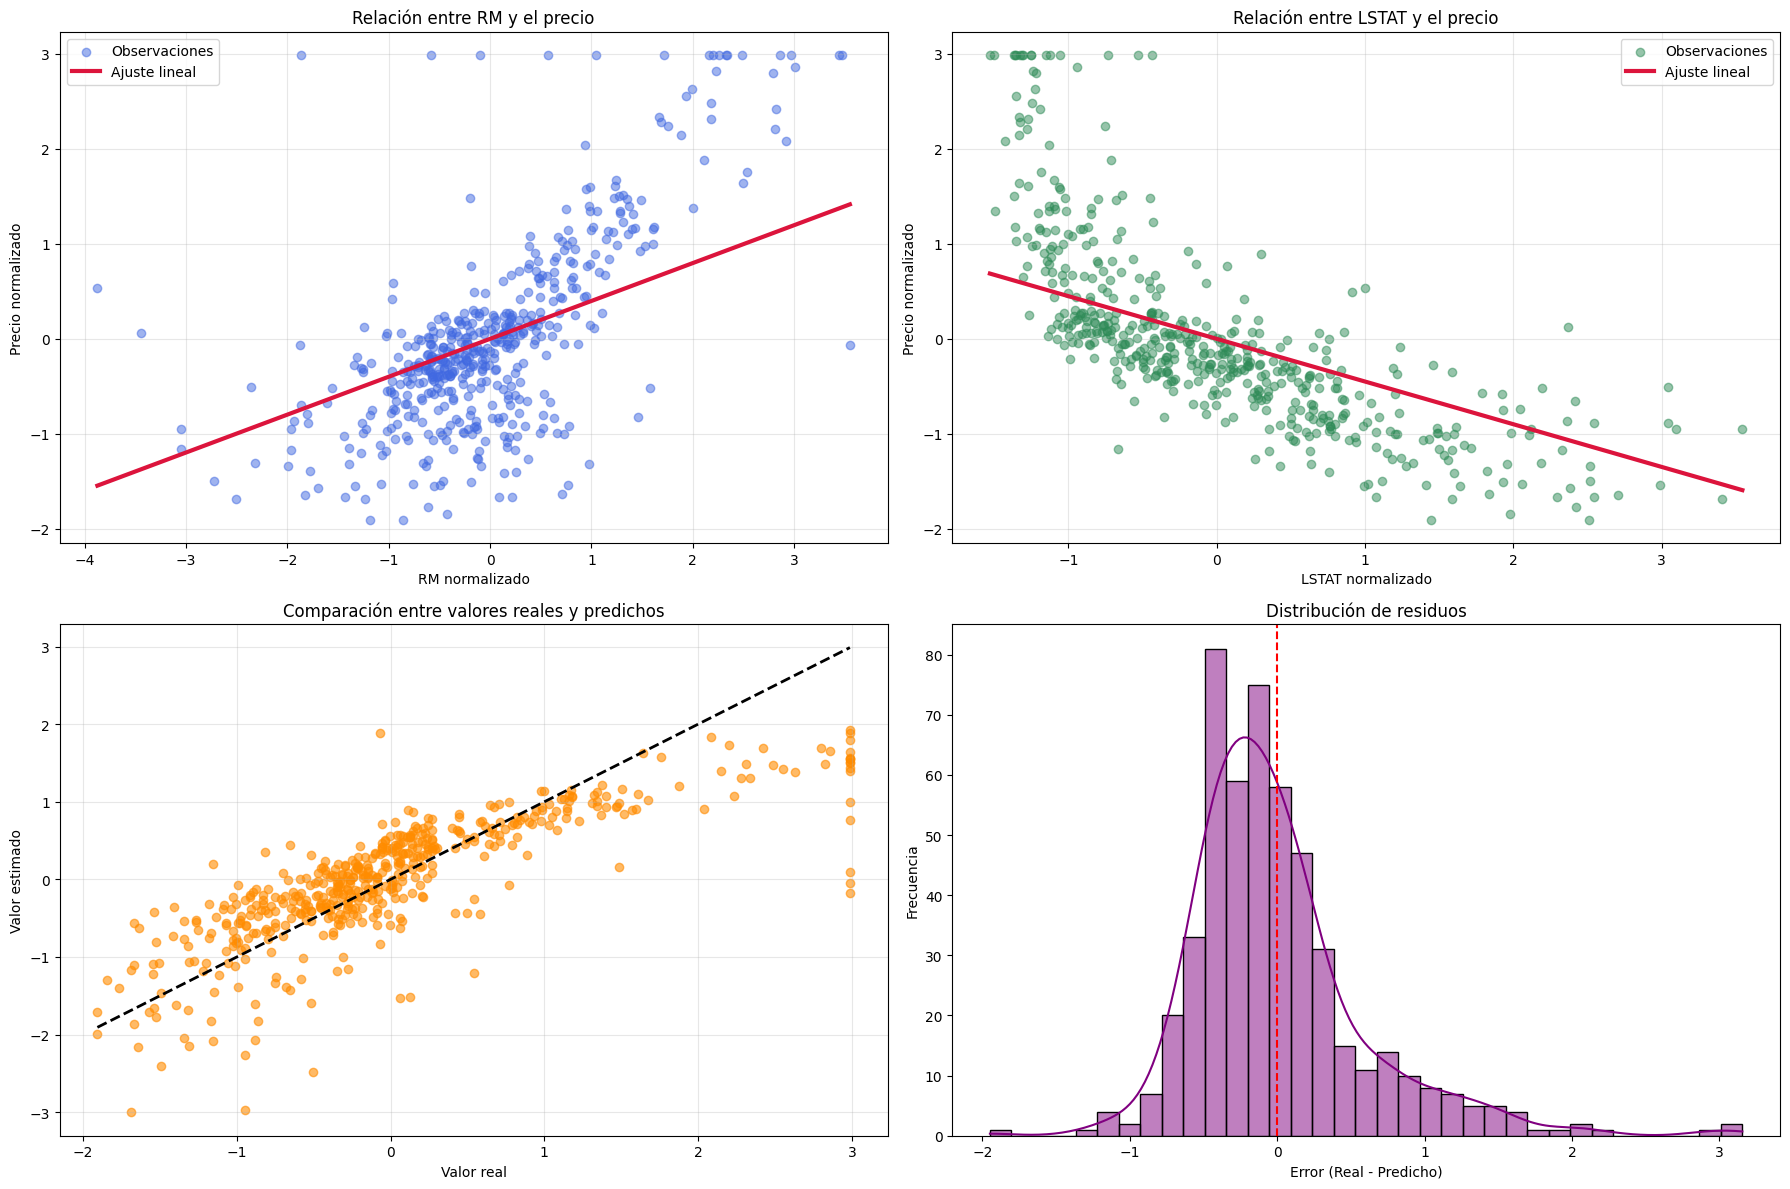

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# VISUALIZACIÓN DEL MODELO DE REGRESIÓN
# =====================================================

# Valores observados y estimados por el modelo
y_real = Y_boston.flatten()
y_estimado = modelo.model().flatten()

# Cálculo de residuos
errores = y_real - y_estimado

# Figura principal
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# =====================================================
# 1. RELACIÓN RM - PRECIO
# =====================================================

ax = axes[0, 0]

ax.scatter(
    df_norm["RM"],
    y_real,
    alpha=0.5,
    color="royalblue",
    label="Observaciones"
)

rm_grid = np.linspace(
    df_norm["RM"].min(),
    df_norm["RM"].max(),
    100
)

precio_rm = modelo.theta[0] + modelo.theta[2] * rm_grid

ax.plot(
    rm_grid,
    precio_rm,
    color="crimson",
    linewidth=3,
    label="Ajuste lineal"
)

ax.set_title("Relación entre RM y el precio")
ax.set_xlabel("RM normalizado")
ax.set_ylabel("Precio normalizado")
ax.legend()
ax.grid(alpha=0.3)

# =====================================================
# 2. RELACIÓN LSTAT - PRECIO
# =====================================================

ax = axes[0, 1]

ax.scatter(
    df_norm["LSTAT"],
    y_real,
    alpha=0.5,
    color="seagreen",
    label="Observaciones"
)

lstat_grid = np.linspace(
    df_norm["LSTAT"].min(),
    df_norm["LSTAT"].max(),
    100
)

precio_lstat = modelo.theta[0] + modelo.theta[3] * lstat_grid

ax.plot(
    lstat_grid,
    precio_lstat,
    color="crimson",
    linewidth=3,
    label="Ajuste lineal"
)

ax.set_title("Relación entre LSTAT y el precio")
ax.set_xlabel("LSTAT normalizado")
ax.set_ylabel("Precio normalizado")
ax.legend()
ax.grid(alpha=0.3)

# =====================================================
# 3. VALORES REALES VS PREDICHOS
# =====================================================

ax = axes[1, 0]

ax.scatter(
    y_real,
    y_estimado,
    alpha=0.6,
    color="darkorange"
)

lim_inf = y_real.min()
lim_sup = y_real.max()

ax.plot(
    [lim_inf, lim_sup],
    [lim_inf, lim_sup],
    "k--",
    linewidth=2
)

ax.set_title("Comparación entre valores reales y predichos")
ax.set_xlabel("Valor real")
ax.set_ylabel("Valor estimado")
ax.grid(alpha=0.3)

# =====================================================
# 4. ANÁLISIS DE RESIDUOS
# =====================================================

ax = axes[1, 1]

sns.histplot(
    errores,
    kde=True,
    color="purple",
    ax=ax
)

ax.axvline(
    0,
    color="red",
    linestyle="--"
)

ax.set_title("Distribución de residuos")
ax.set_xlabel("Error (Real - Predicho)")
ax.set_ylabel("Frecuencia")

# =====================================================
# AJUSTE FINAL
# =====================================================

plt.tight_layout()
plt.show()

### Análisis de las gráficas

Las visualizaciones permiten evaluar tanto la influencia de las variables seleccionadas sobre el precio de las viviendas como la calidad del modelo de regresión construido.

**1. Relación entre RM y el precio**

La primera gráfica muestra una tendencia positiva entre el número promedio de habitaciones (**RM**) y el precio de las viviendas. La pendiente ascendente de la recta de ajuste indica que, en general, las casas con más habitaciones tienden a tener un mayor valor de mercado. Aunque existe dispersión en los datos, la relación lineal es claramente observable.

**2. Relación entre LSTAT y el precio**

En la segunda gráfica se aprecia una relación inversa entre **LSTAT** (porcentaje de población de bajos ingresos) y el precio de las viviendas. La pendiente negativa de la recta de regresión sugiere que, a medida que aumenta esta variable, el valor de las propiedades tiende a disminuir. Esta tendencia es consistente con el comportamiento esperado para este conjunto de datos.

**3. Comparación entre valores reales y predichos**

La tercera gráfica compara los valores reales con las predicciones del modelo. Si el ajuste fuera perfecto, todos los puntos se ubicarían sobre la línea diagonal. Se observa que la mayoría de las observaciones siguen esta tendencia, lo que indica una capacidad predictiva razonablemente buena. Sin embargo, también existen desviaciones apreciables, especialmente en los valores extremos, evidenciando que el modelo no captura completamente toda la variabilidad presente en los datos.

**4. Distribución de residuos**

El histograma de residuos muestra una distribución aproximadamente centrada alrededor de cero, lo que indica que el modelo no presenta un sesgo sistemático importante en sus predicciones. No obstante, se observa una ligera asimetría y la presencia de algunos valores extremos, sugiriendo que ciertos factores relevantes para explicar el precio de las viviendas no están siendo considerados por el modelo.

### Conclusión

En conjunto, las gráficas muestran que las variables **RM**, **LSTAT** y **CRIM** capturan una parte significativa del comportamiento del precio de las viviendas en Boston. El modelo reproduce adecuadamente las tendencias generales de los datos y genera predicciones razonables, aunque la dispersión observada y la presencia de residuos relativamente grandes indican que existen otros factores que también influyen en el valor de las propiedades y que no han sido incluidos en esta aproximación.